# 🔍 NDN Anomaly Detection — Isolation Forest Pipeline
**Named Data Network** monitoring using Isolation Forest for unsupervised anomaly detection.

### Pipeline Overview
1. **Data Extraction** — Parse JSONL logs from all nodes
2. **Data Cleaning** — Remove error entries, handle missing values
3. **Feature Engineering** — Derive rate-based and ratio features
4. **Model Training** — Single Isolation Forest on all-node normal traffic
5. **Model Saving/Loading** — Persist model and scaler
6. **Evaluation & Testing** — Score distributions, threshold tuning
7. **Real-Time Inference Engine** — Per-node streaming anomaly detection

---
## 📦 0. Install & Import Dependencies

In [3]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib tqdm

In [2]:
# Install if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib tqdm

import os
import json
import glob
import warnings
import joblib
from pathlib import Path
from datetime import datetime
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("✅ All imports successful")

✅ All imports successful


---
## ⚙️ 1. Configuration

In [4]:
# ─── USER CONFIG ──────────────────────────────────────────────────────────────
MININDN_DIR = "../Logs/minindn"          # Root folder containing node subfolders
MODEL_DIR   = "../Models"           # Where to save trained model artifacts
RESULTS_DIR = "../Results"          # Where to save evaluation plots/CSVs

# Isolation Forest hyperparameters
IF_CONTAMINATION = 0.05   # Expected fraction of anomalies (tune as needed)
IF_N_ESTIMATORS  = 200
IF_MAX_SAMPLES   = 'auto'
IF_RANDOM_STATE  = 42

# Anomaly score threshold (lower = more anomalous in sklearn; -0.1 is typical)
# We use the percentile approach for auto-thresholding after training
ANOMALY_PERCENTILE = 5   # Bottom 5% of scores flagged as anomalies

# Feature columns produced by feature engineering
FEATURE_COLS = [
    'pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio',
    'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate',
    'out_interests_rate', 'in_data_rate', 'nack_rate'
]

# Create output directories
for d in [MODEL_DIR, RESULTS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"📁 Minindn root : {os.path.abspath(MININDN_DIR)}")
print(f"💾 Model output : {os.path.abspath(MODEL_DIR)}")
print(f"📊 Results dir  : {os.path.abspath(RESULTS_DIR)}")

📁 Minindn root : /Users/darshan/college/6th_sem/Minor/Logs/minindn
💾 Model output : /Users/darshan/college/6th_sem/Minor/Models
📊 Results dir  : /Users/darshan/college/6th_sem/Minor/Results


---
## 📂 2. Data Extraction — Parse JSONL Logs

In [5]:
def discover_log_files(minindn_dir: str) -> dict:
    """
    Walk the minindn directory structure and discover all metrics JSONL files.
    Expected layout:
        minindn/<node_name>/normal_traffic_metrics/<node_name>_metrics.jsonl
    
    Returns:
        dict: { node_name: Path(to_jsonl_file) }
    """
    pattern = os.path.join(minindn_dir, "**", "normal_traffic_metrics", "*_metrics.jsonl")
    files   = glob.glob(pattern, recursive=True)
    
    node_files = {}
    for f in sorted(files):
        # node name is the parent-parent folder name
        node_name = Path(f).parent.parent.name
        node_files[node_name] = Path(f)
    
    return node_files


def parse_jsonl_file(filepath: Path) -> pd.DataFrame:
    """
    Parse a single JSONL file, return a raw DataFrame.
    Each line is one JSON object. Silently skips malformed lines.
    """
    records = []
    with open(filepath, 'r') as fh:
        for lineno, line in enumerate(fh, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
                records.append(rec)
            except json.JSONDecodeError:
                print(f"  ⚠️  Malformed JSON at line {lineno} in {filepath.name} — skipped")
    
    return pd.DataFrame(records) if records else pd.DataFrame()


def extract_all_logs(minindn_dir: str) -> pd.DataFrame:
    """
    Discover and parse all node log files into a single combined DataFrame.
    """
    node_files = discover_log_files(minindn_dir)
    
    if not node_files:
        raise FileNotFoundError(
            f"No *_metrics.jsonl files found under '{minindn_dir}'.\n"
            f"Expected: {minindn_dir}/<node>/normal_traffic_metrics/<node>_metrics.jsonl"
        )
    
    print(f"🔎 Found {len(node_files)} node(s): {sorted(node_files.keys())}")
    
    dfs = []
    for node, fpath in tqdm(node_files.items(), desc="Parsing logs"):
        df = parse_jsonl_file(fpath)
        if not df.empty:
            df['_source_node'] = node   # track origin for diagnostics
            dfs.append(df)
        else:
            print(f"  ⚠️  No records in {fpath}")
    
    if not dfs:
        raise ValueError("All log files were empty or unreadable.")
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f"\n📊 Raw records loaded: {len(combined):,}")
    print(f"   Columns: {list(combined.columns)}")
    return combined


# ─── RUN ──────────────────────────────────────────────────────────────────────
raw_df = extract_all_logs(MININDN_DIR)
raw_df.head()

🔎 Found 12 node(s): ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']


Parsing logs: 100%|████████████████████████████| 12/12 [00:00<00:00, 335.43it/s]


📊 Raw records loaded: 6,324
   Columns: ['timestamp', 'node', 'nPitEntries', 'nInInterests', 'nOutInterests', 'nInData', 'nInNacks', 'nOutNacks', 'nSatisfiedInterests', 'nUnsatisfiedInterests', 'nCsEntries', 'nHits', 'nMisses', 'error', '_source_node']


,timestamp,node,nPitEntries,nInInterests,nOutInterests,nInData,nInNacks,nOutNacks,nSatisfiedInterests,nUnsatisfiedInterests,nCsEntries,nHits,nMisses,error,_source_node
0,2026-03-08T06:20:03.063749,c1,3.0,207.0,204.0,185.0,2.0,4.0,179.0,4.0,170.0,0.0,212.0,NaN,c1
1,2026-03-08T06:20:08.091001,c1,3.0,227.0,220.0,199.0,2.0,4.0,193.0,4.0,178.0,0.0,232.0,NaN,c1
2,2026-03-08T06:20:13.115695,c1,3.0,240.0,228.0,207.0,2.0,4.0,201.0,4.0,179.0,0.0,245.0,NaN,c1
3,2026-03-08T06:20:18.150664,c1,3.0,255.0,237.0,215.0,2.0,4.0,212.0,4.0,182.0,2.0,258.0,NaN,c1
4,2026-03-08T06:20:23.196096,c1,3.0,271.0,244.0,222.0,2.0,4.0,224.0,4.0,183.0,7.0,269.0,NaN,c1


---
## 🧹 3. Data Cleaning

In [6]:
# Required metric columns for feature engineering
REQUIRED_COLS = [
    'timestamp', 'node',
    'nPitEntries', 'nInInterests', 'nOutInterests',
    'nInData', 'nInNacks', 'nOutNacks',
    'nSatisfiedInterests', 'nUnsatisfiedInterests',
    'nCsEntries', 'nHits', 'nMisses'
]

def clean_logs(df: pd.DataFrame) -> pd.DataFrame:
    """
    1. Drop error records (any row with an 'error' key populated)
    2. Keep only rows that have all required metric columns
    3. Parse timestamp → datetime
    4. Cast numeric columns to float
    5. Sort by (node, timestamp)
    6. Remove exact duplicates
    """
    n_raw = len(df)
    
    # ── 1. Drop error rows
    if 'error' in df.columns:
        error_mask = df['error'].notna()
        print(f"🗑️  Error records dropped   : {error_mask.sum():,}")
        df = df[~error_mask].copy()
    
    # ── 2. Keep only rows with all required columns present
    metric_cols = [c for c in REQUIRED_COLS if c not in ('timestamp', 'node')]
    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        print(f"⚠️  Missing columns in dataset: {missing_cols}")
    
    available_metrics = [c for c in metric_cols if c in df.columns]
    df = df.dropna(subset=available_metrics)
    
    # ── 3. Parse timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])
    
    # ── 4. Cast numeric columns
    for col in available_metrics:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=available_metrics)
    
    # ── 5. Sort
    df = df.sort_values(['node', 'timestamp']).reset_index(drop=True)
    
    # ── 6. Remove exact duplicates (same node + timestamp)
    before_dedup = len(df)
    df = df.drop_duplicates(subset=['node', 'timestamp'])
    
    print(f"📥 Raw records              : {n_raw:,}")
    print(f"✅ Clean records retained   : {len(df):,}")
    print(f"🔁 Duplicates removed       : {before_dedup - len(df):,}")
    print(f"📡 Nodes present            : {sorted(df['node'].unique())}")
    return df


clean_df = clean_logs(raw_df.copy())
clean_df.head()

🗑️  Error records dropped   : 793
📥 Raw records              : 6,324
✅ Clean records retained   : 5,531
🔁 Duplicates removed       : 0
📡 Nodes present            : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']


,timestamp,node,nPitEntries,nInInterests,nOutInterests,nInData,nInNacks,nOutNacks,nSatisfiedInterests,nUnsatisfiedInterests,nCsEntries,nHits,nMisses,error,_source_node
0,2026-03-08 06:20:03.063749,c1,3.0,207.0,204.0,185.0,2.0,4.0,179.0,4.0,170.0,0.0,212.0,NaN,c1
1,2026-03-08 06:20:08.091001,c1,3.0,227.0,220.0,199.0,2.0,4.0,193.0,4.0,178.0,0.0,232.0,NaN,c1
2,2026-03-08 06:20:13.115695,c1,3.0,240.0,228.0,207.0,2.0,4.0,201.0,4.0,179.0,0.0,245.0,NaN,c1
3,2026-03-08 06:20:18.150664,c1,3.0,255.0,237.0,215.0,2.0,4.0,212.0,4.0,182.0,2.0,258.0,NaN,c1
4,2026-03-08 06:20:23.196096,c1,3.0,271.0,244.0,222.0,2.0,4.0,224.0,4.0,183.0,7.0,269.0,NaN,c1


---
## 🔧 4. Feature Engineering

In [7]:
def safe_ratio(numerator: pd.Series, denominator: pd.Series, fill: float = 0.0) -> pd.Series:
    """Element-wise ratio; returns `fill` when denominator is 0."""
    return np.where(denominator > 0, numerator / denominator, fill)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-node time-series features using delta (diff) values.

    Features produced:
        pit_size, pit_growth_rate, cs_size, cache_hit_ratio,
        satisfaction_ratio, unsatisfied_ratio, in_interests_rate,
        out_interests_rate, in_data_rate, nack_rate
    
    NOTE: The first row per node is dropped because we can't compute
    deltas for it. This is expected and correct.
    """
    feat_frames = []
    
    for node, grp in tqdm(df.groupby('node'), desc="Feature engineering"):
        grp = grp.sort_values('timestamp').copy()
        
        # Time delta in seconds between consecutive measurements
        dt = grp['timestamp'].diff().dt.total_seconds()
        
        # ── Absolute features
        grp['pit_size'] = grp['nPitEntries']
        grp['cs_size']  = grp['nCsEntries']
        
        # ── Rate features (delta / seconds)
        grp['pit_growth_rate']   = grp['nPitEntries'].diff()                        / dt
        grp['in_interests_rate'] = grp['nInInterests'].diff()                       / dt
        grp['out_interests_rate']= grp['nOutInterests'].diff()                      / dt
        grp['in_data_rate']      = grp['nInData'].diff()                            / dt
        grp['nack_rate']         = (grp['nInNacks'] + grp['nOutNacks']).diff()      / dt
        
        # ── Ratio features (use instantaneous values, not deltas)
        hit_plus_miss = grp['nHits'] + grp['nMisses']
        grp['cache_hit_ratio'] = safe_ratio(grp['nHits'], hit_plus_miss, 0.0)
        
        sat_total = grp['nSatisfiedInterests'] + grp['nUnsatisfiedInterests']
        grp['satisfaction_ratio']  = safe_ratio(grp['nSatisfiedInterests'],   sat_total, 0.0)
        grp['unsatisfied_ratio']   = safe_ratio(grp['nUnsatisfiedInterests'], sat_total, 0.0)
        
        feat_frames.append(grp)
    
    feat_df = pd.concat(feat_frames, ignore_index=True)
    
    # Select only the columns we need going forward
    keep_cols = ['timestamp', 'node'] + FEATURE_COLS
    feat_df = feat_df[keep_cols].copy()
    
    # Drop first rows per node (NaN from diff) and any remaining NaNs
    n_before = len(feat_df)
    feat_df = feat_df.dropna(subset=FEATURE_COLS)
    
    # Clip extreme rates to prevent inf/-inf issues
    rate_cols = ['pit_growth_rate','in_interests_rate','out_interests_rate',
                 'in_data_rate','nack_rate']
    for col in rate_cols:
        q_lo = feat_df[col].quantile(0.01)
        q_hi = feat_df[col].quantile(0.99)
        feat_df[col] = feat_df[col].clip(q_lo, q_hi)
    
    feat_df = feat_df.reset_index(drop=True)
    print(f"\n📐 Feature rows (after diff drop + clip): {len(feat_df):,}  (dropped {n_before - len(feat_df):,})")
    return feat_df


feat_df = engineer_features(clean_df)
feat_df.head(10)

Feature engineering: 100%|█████████████████████| 12/12 [00:00<00:00, 439.50it/s]


📐 Feature rows (after diff drop + clip): 5,519  (dropped 12)


,timestamp,node,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate
0,2026-03-08 06:20:08.091001,c1,3.0,0.0,178.0,0.000000,0.979695,0.020305,3.978317,3.182653,2.784822,0.0
1,2026-03-08 06:20:13.115695,c1,3.0,0.0,179.0,0.000000,0.980488,0.019512,2.587222,1.592137,1.592137,0.0
2,2026-03-08 06:20:18.150664,c1,3.0,0.0,182.0,0.007692,0.981481,0.018519,2.979164,1.787499,1.588888,0.0
3,2026-03-08 06:20:23.196096,c1,3.0,0.0,183.0,0.025362,0.982456,0.017544,3.171185,1.387394,1.387394,0.0
4,2026-03-08 06:20:28.229003,c1,3.0,0.0,183.0,0.041237,0.983264,0.016736,2.980385,1.192154,1.390846,0.0
5,2026-03-08 06:20:33.245329,c1,3.0,0.0,184.0,0.055375,0.984064,0.015936,3.189585,1.395444,1.196095,0.0
6,2026-03-08 06:20:38.279602,c1,3.0,0.0,186.0,0.059701,0.985240,0.014760,4.745720,3.586072,2.989531,0.0
7,2026-03-08 06:20:43.299416,c1,3.0,0.0,186.0,0.071429,0.985816,0.014184,2.988159,1.195263,1.195263,0.0
8,2026-03-08 06:20:48.316796,c1,3.0,0.0,186.0,0.082192,0.986348,0.013652,2.989608,1.195843,0.996536,0.0
9,2026-03-08 06:20:53.334170,c1,3.0,0.0,186.0,0.092105,0.986842,0.013158,2.989612,1.195845,1.195845,0.0


In [8]:
# ── Quick feature summary
print("📊 Feature statistics per column:")
feat_df[FEATURE_COLS].describe().round(4)

📊 Feature statistics per column:


,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate
count,5519.0000,5519.0,5519.0000,5519.0000,5519.0000,5519.0000,5519.0000,5519.0000,5519.0000,5519.0
mean,3.0250,0.0,296.1055,0.0338,0.9948,0.0052,2.1963,1.3988,1.2794,0.0
std,0.2963,0.0,112.0664,0.0296,0.0042,0.0042,0.4278,0.4191,0.3073,0.0
min,2.0000,0.0,170.0000,0.0000,0.9701,0.0008,1.9839,1.1903,0.9930,0.0
25%,3.0000,0.0,214.0000,0.0150,0.9938,0.0024,1.9899,1.1939,1.1924,0.0
50%,3.0000,0.0,250.0000,0.0252,0.9962,0.0038,1.9930,1.1958,1.1957,0.0
75%,3.0000,0.0,330.0000,0.0509,0.9976,0.0062,2.1922,1.3950,1.3917,0.0
max,9.0000,0.0,619.0000,0.1543,0.9992,0.0299,4.7457,3.5861,2.9895,0.0


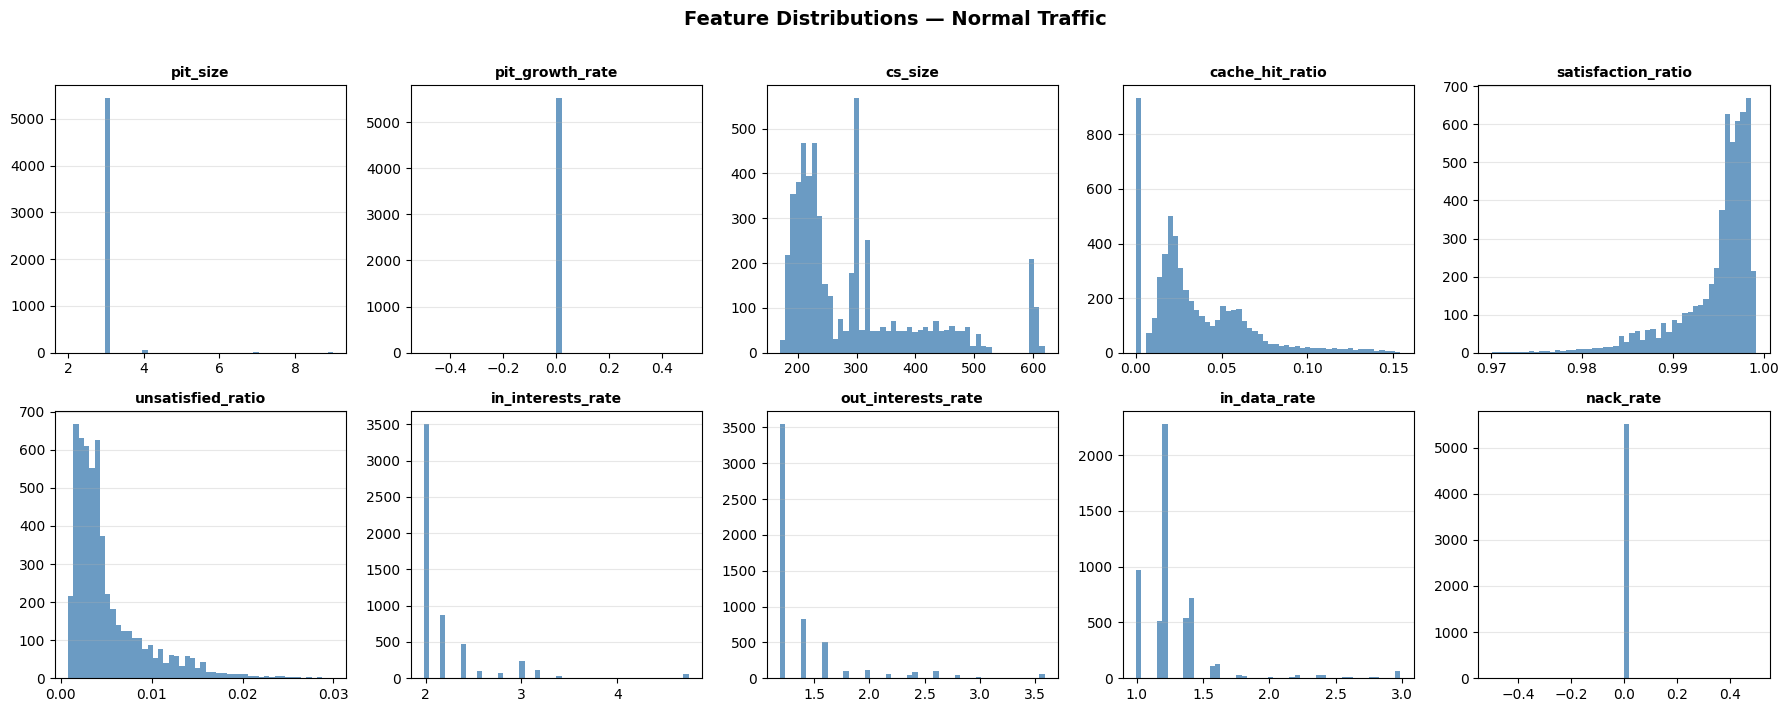

📁 Saved → results/feature_distributions.png


In [9]:
# ── Feature distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(feat_df[col], bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions — Normal Traffic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/feature_distributions.png")

📡 Samples per node:


,n_samples
node,
c1,453
c2,471
c3,473
c4,471
c5,472
c6,472
p1,451
p2,471
r1,379


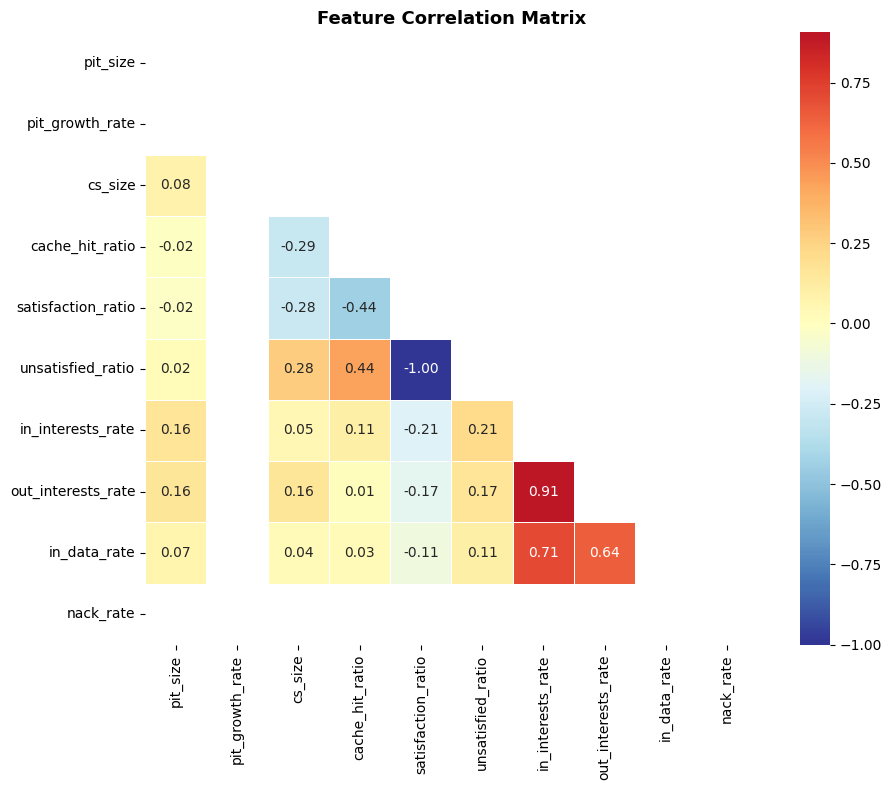

📁 Saved → results/feature_correlation.png


In [10]:
# ── Per-node sample counts
print("📡 Samples per node:")
display(feat_df.groupby('node').size().rename('n_samples').to_frame())

# ── Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = feat_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/feature_correlation.png")

---
## 🤖 5. Model Training — Isolation Forest

In [11]:
def build_training_matrix(feat_df: pd.DataFrame) -> np.ndarray:
    """Extract the numeric feature matrix for training."""
    X = feat_df[FEATURE_COLS].values
    print(f"🧮 Training matrix shape: {X.shape}")
    return X


def train_isolation_forest(X: np.ndarray):
    """
    Build a Pipeline:
        StandardScaler  →  IsolationForest
    
    Returns:
        pipeline : fitted sklearn Pipeline
        threshold : float score below which a point is anomalous
    """
    print(f"🌲 Training Isolation Forest (n_estimators={IF_N_ESTIMATORS}, "
          f"contamination={IF_CONTAMINATION}) ...")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('iforest', IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            contamination=IF_CONTAMINATION,
            max_samples=IF_MAX_SAMPLES,
            random_state=IF_RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    
    pipeline.fit(X)
    print("✅ Training complete.")
    
    # Compute anomaly scores on training data
    scores = pipeline.decision_function(X)   # higher = more normal
    
    # Auto-threshold: bottom ANOMALY_PERCENTILE% of normal scores
    threshold = np.percentile(scores, ANOMALY_PERCENTILE)
    print(f"📏 Auto-threshold (p{ANOMALY_PERCENTILE} of training scores): {threshold:.6f}")
    
    return pipeline, threshold, scores


X_train = build_training_matrix(feat_df)
pipeline, THRESHOLD, train_scores = train_isolation_forest(X_train)

🧮 Training matrix shape: (5519, 10)
🌲 Training Isolation Forest (n_estimators=200, contamination=0.05) ...
✅ Training complete.
📏 Auto-threshold (p5 of training scores): 0.000000


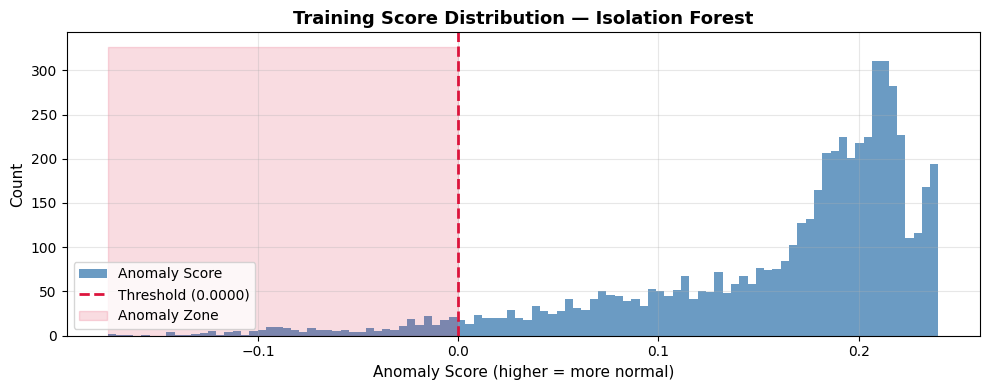

📁 Saved → results/training_score_distribution.png


In [12]:
# ── Training score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_scores, bins=100, color='steelblue', alpha=0.8, edgecolor='none', label='Anomaly Score')
ax.axvline(THRESHOLD, color='crimson', linewidth=2, linestyle='--', label=f'Threshold ({THRESHOLD:.4f})')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  train_scores.min(), THRESHOLD,
                  alpha=0.15, color='crimson', label='Anomaly Zone')
ax.set_xlabel('Anomaly Score (higher = more normal)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Training Score Distribution — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/training_score_distribution.png")

In [13]:
# ── Per-node score distribution on training data
feat_df_scored = feat_df.copy()
feat_df_scored['anomaly_score'] = train_scores
feat_df_scored['is_anomaly']    = (train_scores < THRESHOLD).astype(int)

node_summary = feat_df_scored.groupby('node').agg(
    n_samples   = ('anomaly_score', 'count'),
    mean_score  = ('anomaly_score', 'mean'),
    min_score   = ('anomaly_score', 'min'),
    n_anomalies = ('is_anomaly', 'sum')
).round(4)
node_summary['anomaly_pct'] = (node_summary['n_anomalies'] / node_summary['n_samples'] * 100).round(2)

print("📡 Per-node training score summary:")
display(node_summary)

📡 Per-node training score summary:


,n_samples,mean_score,min_score,n_anomalies,anomaly_pct
node,,,,,
c1,453,0.1775,-0.1664,32,7.06
c2,471,0.1865,-0.1564,18,3.82
c3,473,0.1843,-0.1261,15,3.17
c4,471,0.1814,-0.1261,15,3.18
c5,472,0.1845,-0.1269,16,3.39
c6,472,0.1806,-0.1293,18,3.81
p1,451,0.1796,-0.1226,5,1.11
p2,471,0.1723,-0.1240,8,1.70
r1,379,0.1296,-0.1418,34,8.97


---
## 💾 6. Model Saving

In [14]:
MODEL_PATH     = os.path.join(MODEL_DIR, "ndn_isolation_forest.joblib")
THRESHOLD_PATH = os.path.join(MODEL_DIR, "ndn_threshold.json")
FEATURES_PATH  = os.path.join(MODEL_DIR, "feature_cols.json")

# Save pipeline (scaler + model)
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Pipeline saved → {MODEL_PATH}")

# Save threshold
meta = {
    'threshold': float(THRESHOLD),
    'contamination': IF_CONTAMINATION,
    'anomaly_percentile': ANOMALY_PERCENTILE,
    'n_estimators': IF_N_ESTIMATORS,
    'trained_on_nodes': sorted(feat_df['node'].unique().tolist()),
    'n_training_samples': int(len(X_train)),
    'trained_at': datetime.utcnow().isoformat()
}
with open(THRESHOLD_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✅ Threshold metadata saved → {THRESHOLD_PATH}")

# Save feature column order (critical for inference)
with open(FEATURES_PATH, 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f"✅ Feature columns saved → {FEATURES_PATH}")

✅ Pipeline saved → ../Models/ndn_isolation_forest.joblib
✅ Threshold metadata saved → ../Models/ndn_threshold.json
✅ Feature columns saved → ../Models/feature_cols.json


---
## 📥 7. Model Loading (verify round-trip)

In [15]:
def load_model(model_dir: str = MODEL_DIR):
    """
    Load the saved pipeline, threshold, and feature columns.
    Returns:
        pipeline   : sklearn Pipeline (scaler + iforest)
        threshold  : float
        feat_cols  : list[str]
        meta       : dict with training metadata
    """
    pipeline  = joblib.load(os.path.join(model_dir, "ndn_isolation_forest.joblib"))
    with open(os.path.join(model_dir, "ndn_threshold.json")) as f:
        meta = json.load(f)
    with open(os.path.join(model_dir, "feature_cols.json")) as f:
        feat_cols = json.load(f)
    
    threshold = meta['threshold']
    print(f"✅ Model loaded from '{model_dir}'")
    print(f"   Threshold         : {threshold:.6f}")
    print(f"   Trained on nodes  : {meta['trained_on_nodes']}")
    print(f"   Training samples  : {meta['n_training_samples']:,}")
    print(f"   Feature columns   : {feat_cols}")
    return pipeline, threshold, feat_cols, meta


loaded_pipeline, loaded_threshold, loaded_feat_cols, loaded_meta = load_model()

# Quick sanity check
test_scores = loaded_pipeline.decision_function(X_train[:5])
orig_scores = pipeline.decision_function(X_train[:5])
assert np.allclose(test_scores, orig_scores), "Loaded model doesn't match original!"
print("\n🎯 Round-trip check passed — loaded model is identical.")

✅ Model loaded from '../Models'
   Threshold         : 0.000000
   Trained on nodes  : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']
   Training samples  : 5,519
   Feature columns   : ['pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio', 'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate', 'out_interests_rate', 'in_data_rate', 'nack_rate']

🎯 Round-trip check passed — loaded model is identical.


---
## 🧪 8. Testing & Evaluation on Training Data

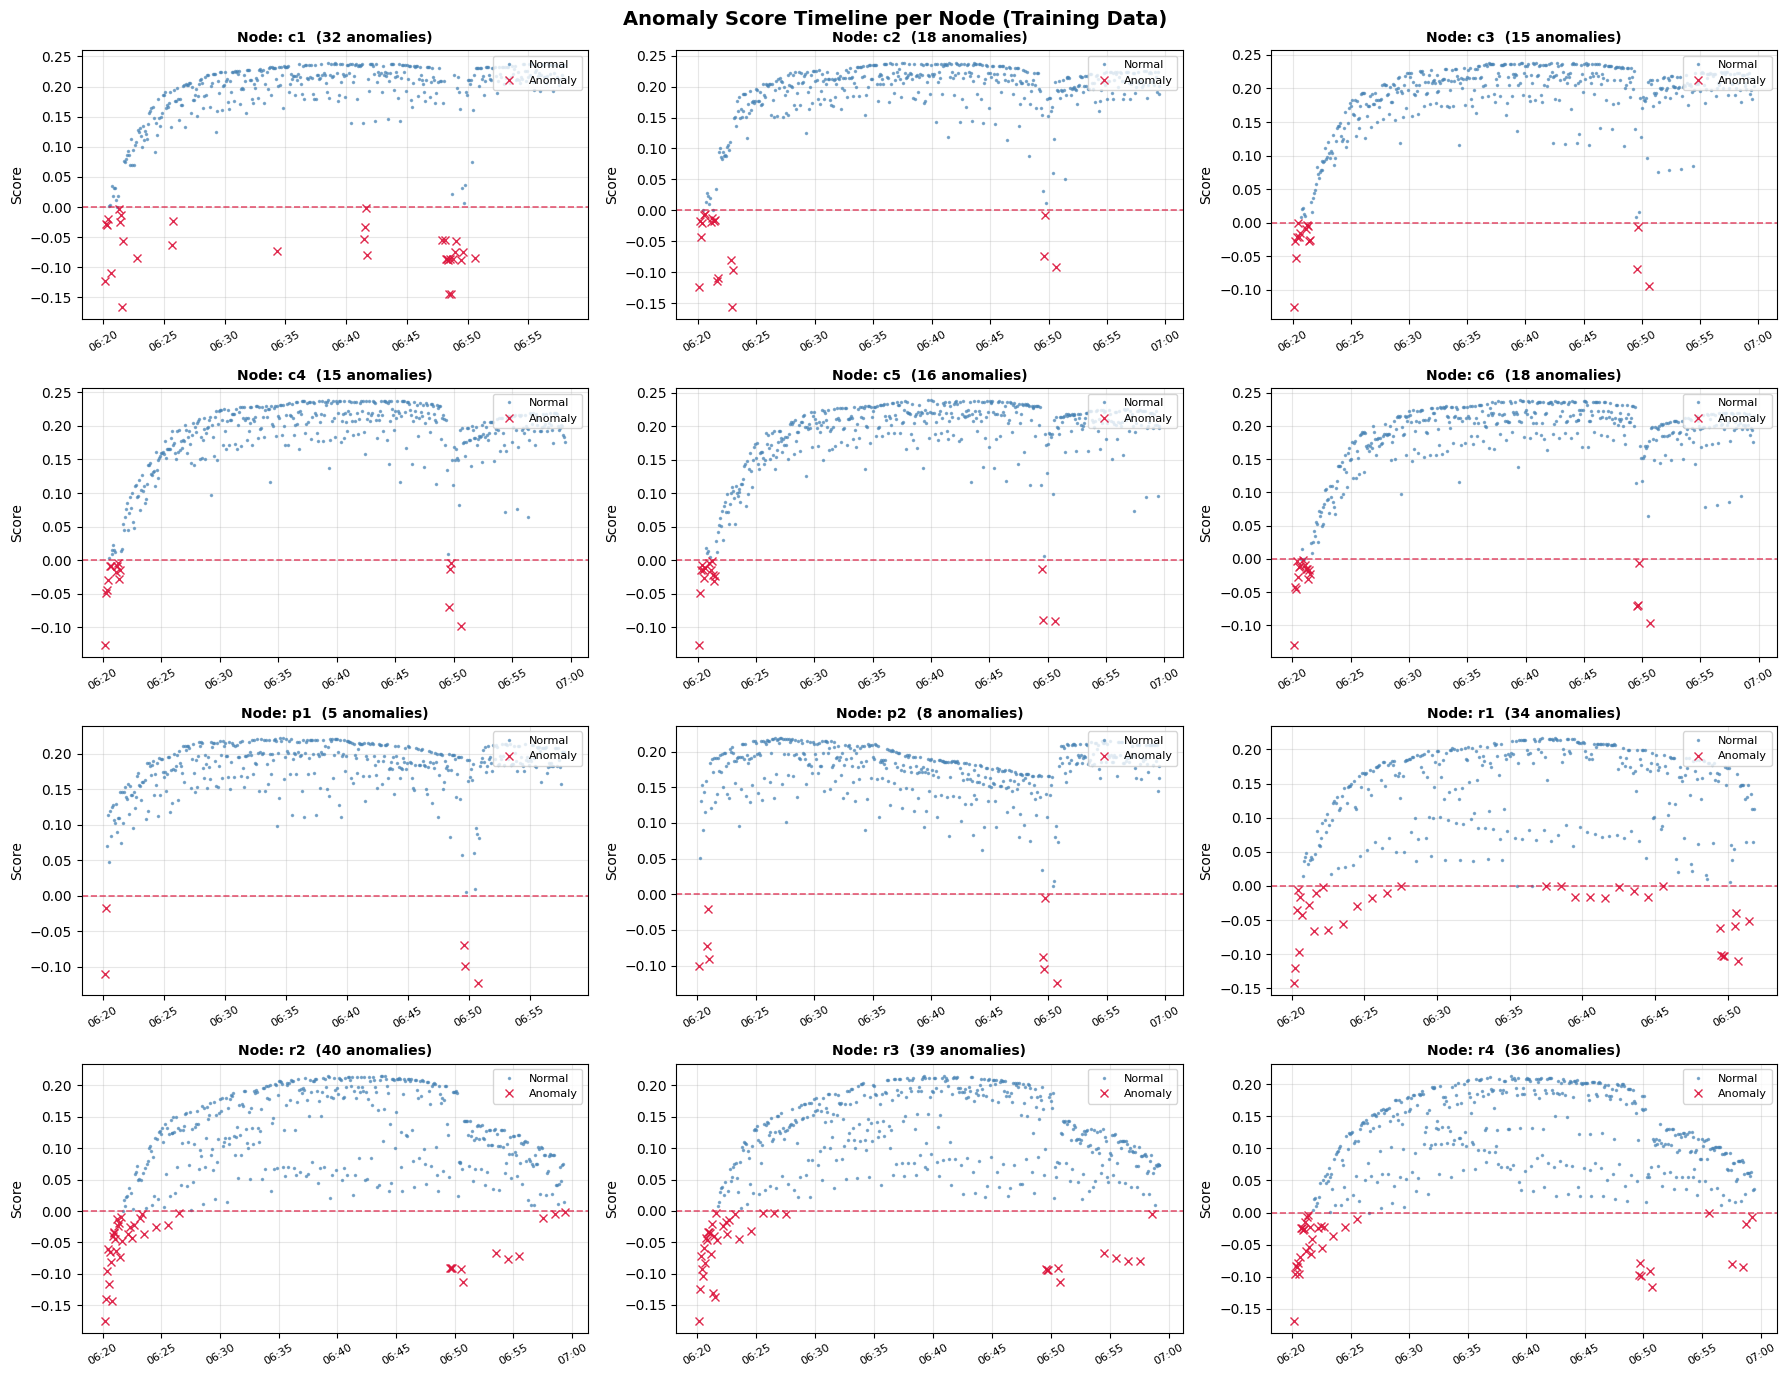

📁 Saved → results/per_node_anomaly_timeline.png


In [16]:
# ── Per-node anomaly timeline plot
nodes = sorted(feat_df_scored['node'].unique())
n_nodes = len(nodes)
n_cols = min(3, n_nodes)
n_rows = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), squeeze=False)

for idx, node in enumerate(nodes):
    ax  = axes[idx // n_cols][idx % n_cols]
    grp = feat_df_scored[feat_df_scored['node'] == node].sort_values('timestamp')
    
    normal    = grp[grp['is_anomaly'] == 0]
    anomalous = grp[grp['is_anomaly'] == 1]
    
    ax.plot(normal['timestamp'],    normal['anomaly_score'],    '.', color='steelblue',  markersize=3, alpha=0.6, label='Normal')
    ax.plot(anomalous['timestamp'], anomalous['anomaly_score'], 'x', color='crimson',    markersize=6, alpha=0.9, label='Anomaly')
    ax.axhline(THRESHOLD, color='crimson', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'Node: {node}  ({len(anomalous)} anomalies)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

# Hide unused subplots
for idx in range(n_nodes, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle('Anomaly Score Timeline per Node (Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_node_anomaly_timeline.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/per_node_anomaly_timeline.png")

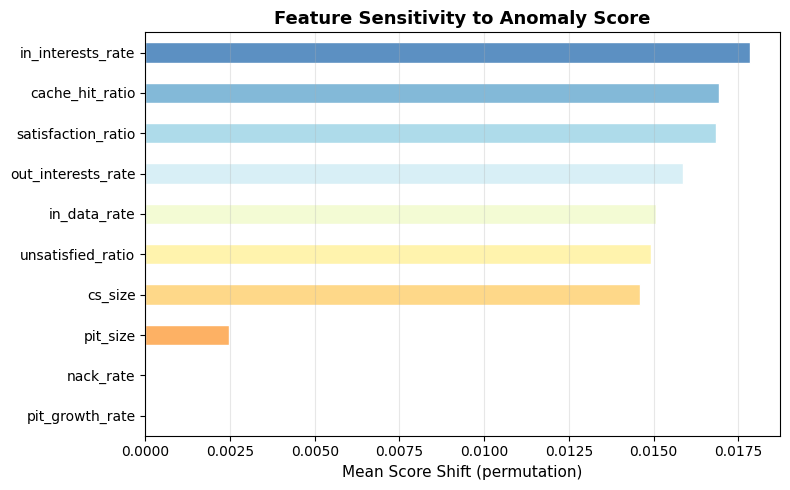

📁 Saved → results/feature_importance.png


In [17]:
# ── Feature importance proxy: mean absolute SHAP-like impact
# (We use permutation sensitivity as IF doesn't give feature importances natively)
base_scores = pipeline.decision_function(X_train)
importance = {}

for i, col in enumerate(FEATURE_COLS):
    X_perm = X_train.copy()
    np.random.shuffle(X_perm[:, i])
    perm_scores = pipeline.decision_function(X_perm)
    importance[col] = np.abs(base_scores - perm_scores).mean()

imp_series = pd.Series(importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.RdYlBu(np.linspace(0.15, 0.85, len(imp_series)))
imp_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Mean Score Shift (permutation)', fontsize=11)
ax.set_title('Feature Sensitivity to Anomaly Score', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/feature_importance.png")

In [18]:
# Save scored training data as CSV for reference
out_csv = os.path.join(RESULTS_DIR, "training_scored.csv")
feat_df_scored.to_csv(out_csv, index=False)
print(f"📁 Scored training data saved → {out_csv}")

📁 Scored training data saved → ../Results/training_scored.csv


---
## 🚀 9. Real-Time Inference Engine

The `NDNAnomalyDetector` class is the core component of your production monitoring tool.
It maintains a **rolling buffer per node**, extracts features from consecutive log entries,
and emits per-node anomaly alerts in real time.

In [26]:
class NDNAnomalyDetector:
    """
    Real-time anomaly detector for Named Data Networks.

    Usage:
        detector = NDNAnomalyDetector.from_saved(MODEL_DIR)

        # Feed a single raw log JSON dict per call:
        result = detector.ingest(log_entry)
        if result['is_anomaly']:
            alert(result)
    """

    REQUIRED_METRICS = [
        'nPitEntries', 'nInInterests', 'nOutInterests',
        'nInData', 'nInNacks', 'nOutNacks',
        'nSatisfiedInterests', 'nUnsatisfiedInterests',
        'nCsEntries', 'nHits', 'nMisses'
    ]

    def __init__(self, pipeline, threshold: float, feature_cols: list,
                 buffer_size: int = 5):
        """
        Args:
            pipeline      : fitted sklearn Pipeline (scaler + IsolationForest)
            threshold     : decision score below which a point is anomalous
            feature_cols  : ordered list of feature names (must match training)
            buffer_size   : how many past entries to keep per node (min 2)
        """
        self.pipeline     = pipeline
        self.threshold    = threshold
        self.feature_cols = feature_cols
        self.buffer_size  = max(buffer_size, 2)

        # { node_name: deque of raw metric dicts (most recent last) }
        self._buffers: dict = {}

    # ── Class method: load from disk ─────────────────────────────────────────
    @classmethod
    def from_saved(cls, model_dir: str, buffer_size: int = 5) -> 'NDNAnomalyDetector':
        """
        Instantiate by loading model artifacts from disk.
        """
        pipeline_, threshold_, feat_cols_, _ = load_model(model_dir)
        return cls(pipeline_, threshold_, feat_cols_, buffer_size)

    # ── Internal helpers ─────────────────────────────────────────────────────
    def _is_valid(self, entry: dict) -> bool:
        """Return True if entry has all required metric fields (no error)."""
        if 'error' in entry and entry['error']:
            return False
        return all(k in entry for k in ['timestamp', 'node'] + self.REQUIRED_METRICS)

    def _parse_entry(self, entry: dict) -> dict:
        """Parse timestamp and cast all numeric fields."""
        parsed = dict(entry)
        parsed['timestamp'] = pd.to_datetime(entry['timestamp'])
        for k in self.REQUIRED_METRICS:
            parsed[k] = float(entry[k])
        return parsed

    def _compute_features(self, prev: dict, curr: dict) -> np.ndarray:
        """Compute feature vector from two consecutive log entries."""
        dt = (curr['timestamp'] - prev['timestamp']).total_seconds()
        if dt <= 0:
            dt = 1.0  # avoid division by zero for identical timestamps

        def rate(key):
            return (curr[key] - prev[key]) / dt

        def safe_ratio(num, den):
            return num / den if den > 0 else 0.0

        hit_plus_miss = curr['nHits'] + curr['nMisses']
        sat_total     = curr['nSatisfiedInterests'] + curr['nUnsatisfiedInterests']

        features = {
            'pit_size'           : curr['nPitEntries'],
            'pit_growth_rate'    : rate('nPitEntries'),
            'cs_size'            : curr['nCsEntries'],
            'cache_hit_ratio'    : safe_ratio(curr['nHits'], hit_plus_miss),
            'satisfaction_ratio' : safe_ratio(curr['nSatisfiedInterests'], sat_total),
            'unsatisfied_ratio'  : safe_ratio(curr['nUnsatisfiedInterests'], sat_total),
            'in_interests_rate'  : rate('nInInterests'),
            'out_interests_rate' : rate('nOutInterests'),
            'in_data_rate'       : rate('nInData'),
            'nack_rate'          : rate('nInNacks') + rate('nOutNacks'),
        }
        # Return in exact training order
        return np.array([features[c] for c in self.feature_cols], dtype=float).reshape(1, -1)

    # ── Public API ────────────────────────────────────────────────────────────
    def ingest(self, raw_entry: dict) -> dict:
        """
        Process one raw log dictionary.

        Args:
            raw_entry: dict parsed from a single JSONL line

        Returns:
            dict with keys:
                node         : str
                timestamp    : datetime
                status       : 'scored' | 'buffering' | 'skipped'
                anomaly_score: float or None
                is_anomaly   : bool or None
                features     : dict or None
                alert        : str (human-readable alert message)
        """
        # ── Skip invalid/error entries
        if not self._is_valid(raw_entry):
            return {
                'node': raw_entry.get('node', 'unknown'),
                'timestamp': raw_entry.get('timestamp'),
                'status': 'skipped',
                'anomaly_score': None,
                'is_anomaly': None,
                'features': None,
                'alert': ''
            }

        entry = self._parse_entry(raw_entry)
        node  = entry['node']

        # ── Initialise buffer for new nodes
        if node not in self._buffers:
            self._buffers[node] = deque(maxlen=self.buffer_size)

        buf = self._buffers[node]

        # Need at least 1 previous entry to compute deltas
        if len(buf) == 0:
            buf.append(entry)
            return {
                'node': node,
                'timestamp': entry['timestamp'],
                'status': 'buffering',
                'anomaly_score': None,
                'is_anomaly': None,
                'features': None,
                'alert': f'[{node}] First entry buffered — warming up…'
            }

        # ── Compute features using (prev, curr) pair
        prev  = buf[-1]
        X_vec = self._compute_features(prev, entry)

        # ── Predict
        score      = float(self.pipeline.decision_function(X_vec)[0])
        is_anomaly = score < self.threshold

        # ── Update buffer
        buf.append(entry)

        # ── Build feature dict for logging
        feat_dict = dict(zip(self.feature_cols, X_vec[0].tolist()))

        # ── Build alert message
        if is_anomaly:
            top_feat = sorted(feat_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
            top_str  = ', '.join(f'{k}={v:.3f}' for k, v in top_feat)
            alert_msg = (f"🚨 ANOMALY on [{node}] @ {entry['timestamp']} "
                         f"| score={score:.4f} (threshold={self.threshold:.4f}) "
                         f"| top features: {top_str}")
        else:
            alert_msg = f"✅ Normal  [{node}] @ {entry['timestamp']} | score={score:.4f}"

        return {
            'node'         : node,
            'timestamp'    : entry['timestamp'],
            'status'       : 'scored',
            'anomaly_score': score,
            'is_anomaly'   : is_anomaly,
            'features'     : feat_dict,
            'alert'        : alert_msg
        }

    def reset_node(self, node: str):
        """Clear the buffer for a specific node (use after node restart)."""
        self._buffers.pop(node, None)
        print(f"🔄 Buffer reset for node '{node}'")

    def reset_all(self):
        """Clear all node buffers."""
        self._buffers.clear()
        print("🔄 All node buffers reset")

    def node_status(self) -> pd.DataFrame:
        """Return a summary DataFrame of current buffer states per node."""
        rows = [
            {'node': node, 'buffer_len': len(buf),
             'last_ts': buf[-1]['timestamp'] if buf else None}
            for node, buf in self._buffers.items()
        ]
        return pd.DataFrame(rows)


print("✅ NDNAnomalyDetector class defined.")

✅ NDNAnomalyDetector class defined.


---
## 🔬 10. Inference Demo — Replay Logs Through Detector

In [25]:
clean_df['error'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [27]:
# ── Instantiate detector from saved model
detector = NDNAnomalyDetector.from_saved(MODEL_DIR)

# ── Replay all raw clean records through the detector (simulates real-time)
# We use clean_df (pre-feature-engineering, the cleaned raw records)
clean_df = clean_df.drop(columns=['error'])
clean_sorted = clean_df.sort_values('timestamp').to_dict(orient='records')

results = []
for entry in tqdm(clean_sorted, desc="Replaying logs"):
    result = detector.ingest(entry)
    results.append(result)

results_df = pd.DataFrame(results)
scored_df  = results_df[results_df['status'] == 'scored'].copy()

print(f"\n📊 Total entries processed : {len(results_df):,}")
print(f"   Scored                  : {len(scored_df):,}")
print(f"   Skipped (errors)        : {(results_df['status'] == 'skipped').sum():,}")
print(f"   Buffering (first/node)  : {(results_df['status'] == 'buffering').sum():,}")
print(f"   Anomalies detected      : {scored_df['is_anomaly'].sum():,}")

✅ Model loaded from '../Models'
   Threshold         : 0.000000
   Trained on nodes  : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']
   Training samples  : 5,519
   Feature columns   : ['pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio', 'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate', 'out_interests_rate', 'in_data_rate', 'nack_rate']


Replaying logs: 100%|██████████████████████| 5531/5531 [00:22<00:00, 247.61it/s]


📊 Total entries processed : 5,531
   Scored                  : 5,519
   Skipped (errors)        : 0
   Buffering (first/node)  : 12
   Anomalies detected      : 276


In [28]:
# ── Print sample anomaly alerts
anomaly_alerts = scored_df[scored_df['is_anomaly'] == True]['alert'].values
print(f"\n🚨 Sample Anomaly Alerts (first 10):")
for a in anomaly_alerts[:10]:
    print(" ", a)


🚨 Sample Anomaly Alerts (first 10):
  🚨 ANOMALY on [c1] @ 2026-03-08 06:20:08.091001 | score=-0.1235 (threshold=0.0000) | top features: cs_size=178.000, in_interests_rate=3.978, out_interests_rate=3.183
  🚨 ANOMALY on [c2] @ 2026-03-08 06:20:08.399935 | score=-0.1244 (threshold=0.0000) | top features: cs_size=176.000, in_interests_rate=3.971, out_interests_rate=3.177
  🚨 ANOMALY on [c3] @ 2026-03-08 06:20:08.685251 | score=-0.1261 (threshold=0.0000) | top features: cs_size=174.000, in_interests_rate=3.987, out_interests_rate=3.189
  🚨 ANOMALY on [c4] @ 2026-03-08 06:20:08.994014 | score=-0.1261 (threshold=0.0000) | top features: cs_size=174.000, in_interests_rate=3.986, out_interests_rate=3.189
  🚨 ANOMALY on [c5] @ 2026-03-08 06:20:09.313485 | score=-0.1269 (threshold=0.0000) | top features: cs_size=172.000, in_interests_rate=3.986, out_interests_rate=3.188
  🚨 ANOMALY on [c6] @ 2026-03-08 06:20:09.613845 | score=-0.1293 (threshold=0.0000) | top features: cs_size=170.000, in_interest

In [29]:
# ── Per-node anomaly summary from inference run
per_node_inference = scored_df.groupby('node').agg(
    total_scored = ('anomaly_score', 'count'),
    anomalies    = ('is_anomaly', 'sum'),
    mean_score   = ('anomaly_score', 'mean'),
    min_score    = ('anomaly_score', 'min')
).round(4)
per_node_inference['anomaly_%'] = (
    per_node_inference['anomalies'] / per_node_inference['total_scored'] * 100
).round(2)

print("📡 Per-node inference summary:")
display(per_node_inference)

📡 Per-node inference summary:


,total_scored,anomalies,mean_score,min_score,anomaly_%
node,,,,,
c1,453,32,0.1775,-0.1664,7.06
c2,471,18,0.1865,-0.1564,3.82
c3,473,15,0.1843,-0.1261,3.17
c4,471,15,0.1814,-0.1261,3.18
c5,472,16,0.1845,-0.1269,3.39
c6,472,18,0.1806,-0.1293,3.81
p1,451,5,0.1796,-0.1226,1.11
p2,471,8,0.1723,-0.1240,1.7
r1,379,34,0.1296,-0.1418,8.97


KeyError: "None of [Index([-2, -2, -2, -2, -1, -1, -2, -1, -1, -1,\n       ...\n       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],\n      dtype='object', length=453)] are in the [columns]"

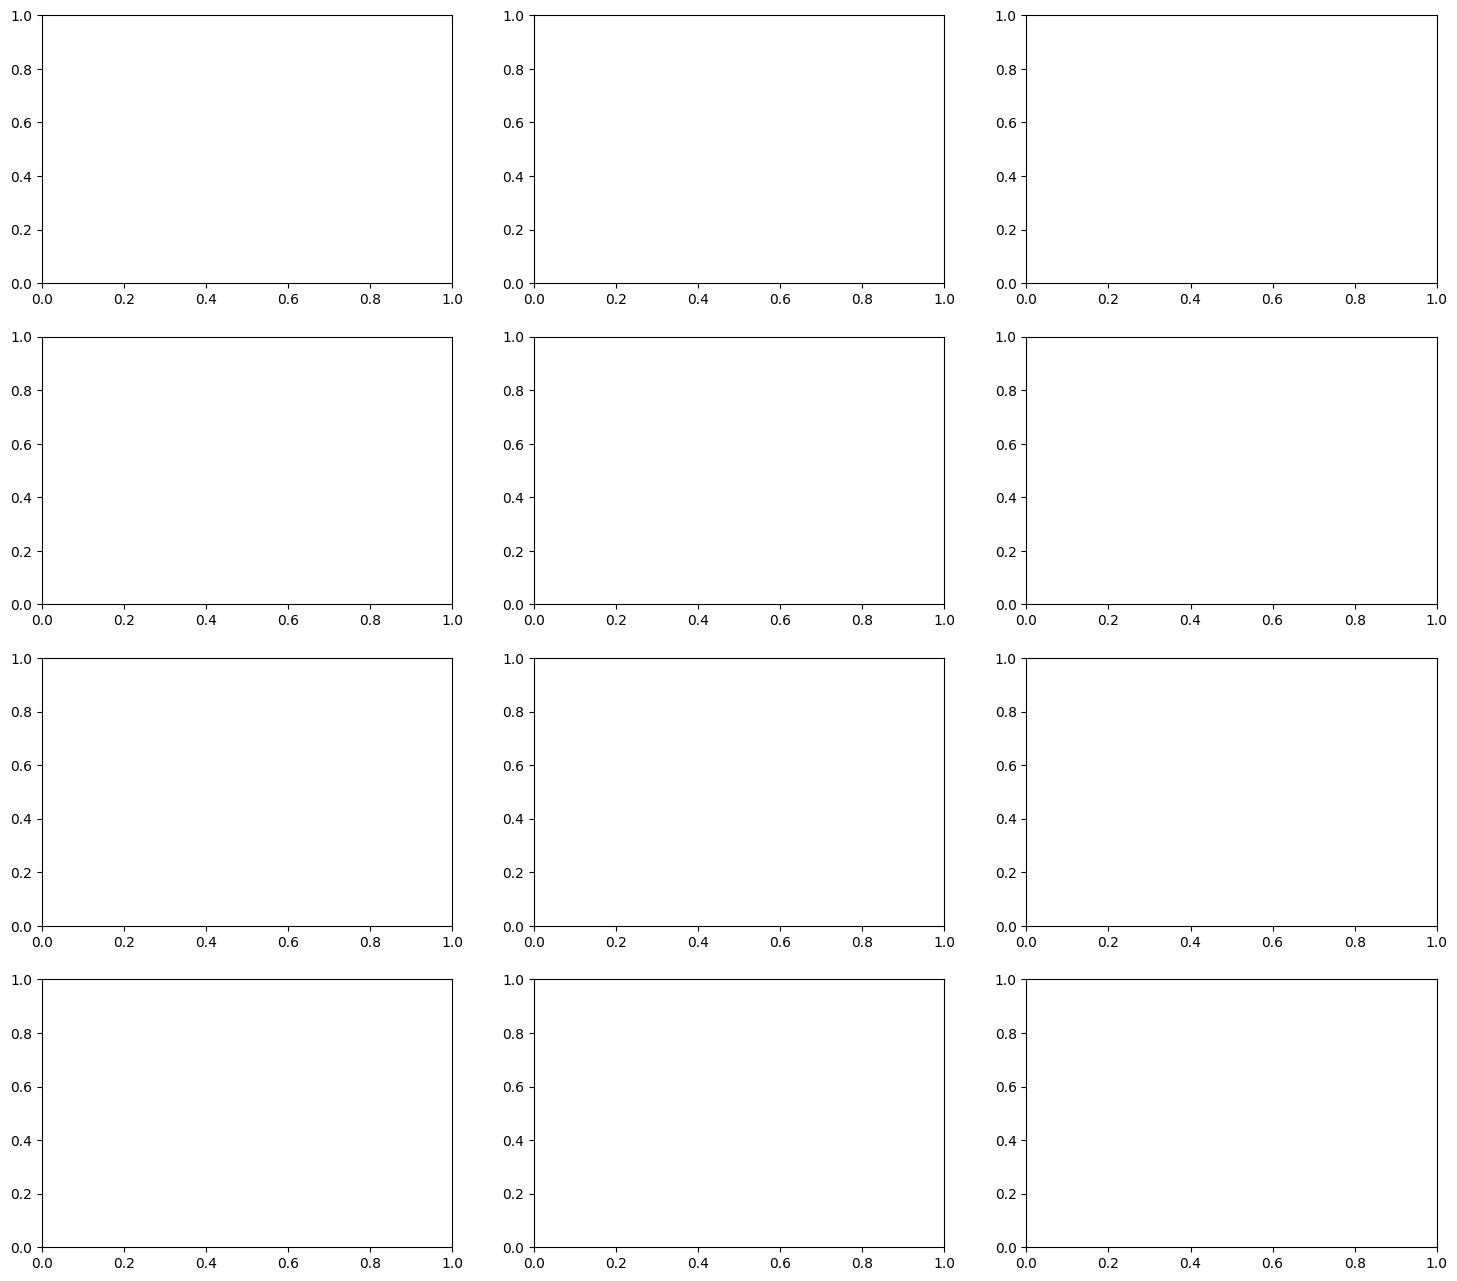

In [30]:
# ── Live-style anomaly timeline plot
nodes = sorted(scored_df['node'].unique())
n_nodes = len(nodes)
n_cols  = min(3, n_nodes)
n_rows  = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

for idx, node in enumerate(nodes):
    ax  = axes[idx // n_cols][idx % n_cols]
    grp = scored_df[scored_df['node'] == node].sort_values('timestamp')
    
    normal    = grp[~grp['is_anomaly']]
    anomalous = grp[grp['is_anomaly']]
    
    ax.fill_between(grp['timestamp'], grp['anomaly_score'], THRESHOLD,
                     where=(grp['anomaly_score'] < THRESHOLD),
                     alpha=0.25, color='crimson', interpolate=True)
    ax.plot(normal['timestamp'],    normal['anomaly_score'],    '.', 
            color='#2196F3', markersize=3, alpha=0.7, label='Normal')
    ax.plot(anomalous['timestamp'], anomalous['anomaly_score'], 'v', 
            color='crimson', markersize=7, alpha=0.9, label=f'Anomaly ({len(anomalous)})')
    ax.axhline(THRESHOLD, color='crimson', linewidth=1.5, linestyle='--', 
               alpha=0.8, label=f'Threshold')
    ax.set_title(f'Node: {node}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Anomaly Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

for idx in range(n_nodes, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle('Real-Time Inference: Anomaly Scores per Node', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/realtime_inference_timeline.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/realtime_inference_timeline.png")

---
## 🎛️ 11. Threshold Tuning (Optional)
If you know labelled anomaly data exists, use this cell to tune the threshold.

In [ ]:
# ── Score distribution vs. percentile thresholds
percentiles = [1, 2, 3, 5, 7, 10, 15]
thresholds  = {p: float(np.percentile(train_scores, p)) for p in percentiles}

print("📏 Threshold sensitivity table:")
header = f"{'Percentile':>12} | {'Threshold':>12} | {'Anomalies (train)':>18} | {'Anomaly %':>10}"
print(header)
print('-' * len(header))
for p, thresh in thresholds.items():
    n_anom = (train_scores < thresh).sum()
    pct    = n_anom / len(train_scores) * 100
    marker = '  ← current' if p == ANOMALY_PERCENTILE else ''
    print(f"{p:>12} | {thresh:>12.6f} | {n_anom:>18,} | {pct:>9.2f}%{marker}")

print("\n💡 To change threshold, update ANOMALY_PERCENTILE and re-run training cells.")

---
## 🧩 12. Production Integration — Minimal Example

Copy this pattern into your monitoring daemon / Kafka consumer / syslog reader.

In [ ]:
# ─────────────────────────────────────────────────────────────
# PRODUCTION TEMPLATE
# ─────────────────────────────────────────────────────────────
#
# import json
# from ndn_detector import NDNAnomalyDetector   # put class in its own module
#
# detector = NDNAnomalyDetector.from_saved("./models")
#
# def on_new_log_line(raw_json_line: str):
#     """Call this for every new line arriving from a node."""
#     try:
#         entry  = json.loads(raw_json_line)
#         result = detector.ingest(entry)
#
#         if result['status'] == 'scored':
#             print(result['alert'])         # or push to Prometheus / InfluxDB / Slack
#             if result['is_anomaly']:
#                 fire_alert(
#                     node      = result['node'],
#                     timestamp = result['timestamp'],
#                     score     = result['anomaly_score'],
#                     features  = result['features']
#                 )
#     except json.JSONDecodeError:
#         pass  # malformed line
#
# ─────────────────────────────────────────────────────────────
print("✅ Integration template above — adapt to your log ingestion layer.")

---
## 📁 13. Output Summary

In [ ]:
print("=" * 60)
print("  NDN ANOMALY DETECTION — OUTPUT FILES")
print("=" * 60)

all_outputs = [
    (MODEL_DIR,   "ndn_isolation_forest.joblib", "Trained pipeline (scaler + IF)"),
    (MODEL_DIR,   "ndn_threshold.json",           "Threshold + training metadata"),
    (MODEL_DIR,   "feature_cols.json",             "Ordered feature column list"),
    (RESULTS_DIR, "feature_distributions.png",     "Feature histogram plots"),
    (RESULTS_DIR, "feature_correlation.png",        "Correlation heatmap"),
    (RESULTS_DIR, "training_score_distribution.png","Score dist + threshold line"),
    (RESULTS_DIR, "per_node_anomaly_timeline.png",  "Training: per-node timelines"),
    (RESULTS_DIR, "feature_importance.png",         "Permutation sensitivity plot"),
    (RESULTS_DIR, "realtime_inference_timeline.png","Inference: anomaly timelines"),
    (RESULTS_DIR, "training_scored.csv",            "CSV with all scored records"),
]

for d, fname, desc in all_outputs:
    fpath = os.path.join(d, fname)
    exists = "✅" if os.path.exists(fpath) else "❌ MISSING"
    print(f"  {exists}  {fpath:<50}  ← {desc}")

print()
print(f"  Model threshold  : {THRESHOLD:.6f}")
print(f"  Training samples : {len(X_train):,}")
print(f"  Nodes trained on : {sorted(feat_df['node'].unique())}")